In [1]:
from transcoder_circuits.circuit_analysis import *
from transcoder_circuits.feature_dashboards import *
from transcoder_circuits.replacement_ctx import *
from sae_training.sparse_autoencoder import SparseAutoencoder
from transformer_lens import HookedTransformer, utils
from back_gradients import *


/home/shuhewang/miniconda3/envs/transcoder/lib/python3.10/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/home/shuhewang/miniconda3/envs/transcoder/lib/python3.10/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/home/shuhewang/miniconda3/envs/transcoder/lib/python3.10/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [2]:
model_name = "gpt2"
vocab_path = "/data/projects/punim2522/models/gpt2/vocab.json"
transcoders_path = "/data/projects/punim2522/models/gpt2-transcoders/final_sparse_autoencoder_gpt2-small_blocks.{}.ln2.hook_normalized_24576"

In [3]:
sub_transcoders_num=2
model = load_model(model_name=model_name)
vocab = load_vocab(vocab_path=vocab_path)
transcoder = load_transcoders(transcoders_path=transcoders_path, sub_transcoders_num=sub_transcoders_num)

/home/shuhewang/miniconda3/envs/transcoder/lib/python3.10/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/shuhewang/miniconda3/envs/transcoder/lib/python3.10/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


Loaded pretrained model gpt2 into HookedTransformer


In [5]:
save_grads = False
model, grads, original_mlps = sub_transcoders_wrapper(model=model, transcoders=transcoder, sub_transcoders_num=sub_transcoders_num, save_grads=save_grads)

In [6]:
prompt = "In the hotel laundry room, Emma burned Mary's shirt, so the manager scolded"
prompt_answer = " Emma"
prompt_answer = [prompt_answer]

tokens_arr = model.to_tokens(prompt)
        
answer_token_indices = torch.tensor([model.to_single_token(prompt_answer[0])], device=model.cfg.device)

print("tokens_arr:", tokens_arr)
print("answer_token_indices:", answer_token_indices)

tokens_arr: tensor([[50256,   818,   262,  7541, 25724,  2119,    11, 18966, 11544,  5335,
           338, 10147,    11,   523,   262,  4706,   629, 48959]],
       device='cuda:0')
answer_token_indices: tensor([18966], device='cuda:0')


In [7]:
logits = model(tokens_arr)

In [8]:
print("logits shape:", logits.shape)

print("top 20 logits:", torch.topk(logits[0, -1], k=20))

print("top 20 words:", [vocab[int(i)] for i in torch.topk(logits[0, -1], k=20).indices])

logits shape: torch.Size([1, 18, 50257])
top 20 logits: torch.return_types.topk(
values=tensor([19.3475, 15.9862, 15.9539, 15.1606, 15.0820, 15.0199, 13.4405, 13.0704,
        13.0163, 12.8985, 12.8879, 12.7449, 12.6283, 12.4854, 12.1359, 12.0501,
        11.9543, 11.9525, 11.7792, 11.6675], device='cuda:0',
       grad_fn=<TopkBackward0>),
indices=tensor([  607,   262,   683,   606, 18966,  5335,   502,   514,   340,  5223,
          290,   465,  2506,   257,  9074,  5850,   673, 17608,  1111,  3409],
       device='cuda:0'))
top 20 words: ['Ġher', 'Ġthe', 'Ġhim', 'Ġthem', 'ĠEmma', 'ĠMary', 'Ġme', 'Ġus', 'Ġit', 'Ġherself', 'Ġand', 'Ġhis', 'Ġeveryone', 'Ġa', 'ĠMrs', 'ĠHarry', 'Ġshe', 'ĠEmily', 'Ġboth', 'ĠSam']


In [9]:
logits[:, -1, answer_token_indices[0]].backward()

In [27]:
print("model.blocks[0].mlp.transcoder.W_dec.grad:", model.blocks[0].mlp.transcoder.W_dec.grad)

print(model.blocks[0].mlp.transcoder.W_dec.grad.shape)

w_dec_values, w_dec_indices = torch.topk(torch.abs(model.blocks[0].mlp.transcoder.W_dec.grad.flatten()), k=20)

w_dec_indices_x = w_dec_indices // model.blocks[0].mlp.transcoder.W_dec.shape[1]
w_dec_indices_y = w_dec_indices % model.blocks[0].mlp.transcoder.W_dec.shape[1]

print("top 20 W_dec gradients values:", w_dec_values)

print("top 20 W_dec gradients w_dec_indices_x:", w_dec_indices_x)

print("top 20 W_dec gradients w_dec_indices_y:", w_dec_indices_y)



model.blocks[0].mlp.transcoder.W_dec.grad: tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0')
torch.Size([24576, 768])
top 20 W_dec gradients values: tensor([0.5972, 0.5944, 0.5386, 0.5246, 0.5242, 0.5054, 0.5031, 0.5018, 0.5006,
        0.4622, 0.4538, 0.4511, 0.4505, 0.4498, 0.4435, 0.4350, 0.4281, 0.4246,
        0.4220, 0.4157], device='cuda:0')
top 20 W_dec gradients w_dec_indices_x: tensor([ 5545,  5545,  5545,  9886,  5545,  5545,  5545,  5545,  9886,  5545,
         9886,  5545,  5545,  5545,  5545, 21547,  5545,  5545,  9886,  5545],
       device='cuda:0')
top 20 W_dec gradients w_dec_indices_y: tensor([420,  36, 688, 745, 432, 657, 439, 276, 137,   0, 393, 139, 707,   4,
        297, 420, 756, 431, 756, 636], device='cuda:0')


In [28]:
print("model.blocks[1].mlp.transcoder.W_enc.grad:", model.blocks[1].mlp.transcoder.W_enc.grad)

print(model.blocks[1].mlp.transcoder.W_enc.grad.shape)

w_enc_values, w_enc_indices = torch.topk(torch.abs(model.blocks[1].mlp.transcoder.W_enc.grad.flatten()), k=20)

# indices = indices % model.blocks[1].mlp.transcoder.W_enc.shape[1]

# print("top 20 W_enc gradients values:", values)

# print("top 20 W_enc gradients indices:", indices)

w_enc_indices_x = w_enc_indices // model.blocks[1].mlp.transcoder.W_enc.shape[1]
w_enc_indices_y = w_enc_indices % model.blocks[1].mlp.transcoder.W_enc.shape[1]

print("top 20 W_enc gradients values:", w_enc_values)

print("top 20 W_enc gradients w_enc_indices_x:", w_enc_indices_x)

print("top 20 W_enc gradients w_enc_indices_y:", w_enc_indices_y)

print("top 20 W_enc gradients indices:", w_enc_indices)

model.blocks[1].mlp.transcoder.W_enc.grad: tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0')
torch.Size([768, 24576])
top 20 W_enc gradients values: tensor([0.4863, 0.4205, 0.3798, 0.3553, 0.3344, 0.3203, 0.3047, 0.2920, 0.2904,
        0.2786, 0.2745, 0.2696, 0.2665, 0.2632, 0.2578, 0.2538, 0.2532, 0.2505,
        0.2438, 0.2419], device='cuda:0')
top 20 W_enc gradients w_enc_indices_x: tensor([480, 393, 480, 216, 288, 393, 645, 283, 278, 628,  25, 640, 439, 288,
        171, 216, 269, 405, 645, 688], device='cuda:0')
top 20 W_enc gradients w_enc_indices_y: tensor([14939, 14939,  7534, 14939, 14939,  7534, 14939, 14939, 14939, 14939,
        14939, 14939, 14939,  7534, 14939,  7534, 14939, 14939,  7534, 14939],
       device='cuda:0')
top 20 W_enc gradients indices: t

In [29]:
feature_idx = 9886

print(torch.topk(torch.abs(model.blocks[1].mlp.transcoder.W_enc.grad[:, feature_idx]), k=20))


print(torch.topk(torch.abs(model.blocks[0].mlp.transcoder.W_dec.grad[feature_idx, :]), k=20))

torch.return_types.topk(
values=tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       device='cuda:0'),
indices=tensor([19, 18, 16, 17,  1,  0,  2,  3, 11, 10,  8,  9, 13, 12, 14, 15,  7,  6,
         4,  5], device='cuda:0'))
torch.return_types.topk(
values=tensor([0.5246, 0.5006, 0.4538, 0.4220, 0.4123, 0.3774, 0.3720, 0.3657, 0.3646,
        0.3644, 0.3531, 0.3314, 0.3263, 0.3213, 0.3107, 0.3067, 0.3004, 0.2988,
        0.2978, 0.2921], device='cuda:0'),
indices=tensor([745, 137, 393, 756, 351, 605, 669, 508, 318, 420, 622, 256, 347, 480,
        642, 627, 274, 303, 754, 640], device='cuda:0'))


In [30]:
print(model.blocks[0].mlp.hidden_acts.shape)

print(model.blocks[0].mlp.hidden_acts[0, 7, 9886])

none_zero = torch.nonzero(model.blocks[0].mlp.hidden_acts)
print(none_zero.shape)

none_zero_7 = torch.nonzero(model.blocks[0].mlp.hidden_acts[0, 7, :])
print(none_zero_7.shape)

sum_ = 0
attention_token_idx = [7, 8, 9, 13, 17]
for idx_ in attention_token_idx:
    print(f"idx_: {idx_}")
    none_zero_current = torch.nonzero(model.blocks[0].mlp.hidden_acts[0, idx_, :])
    print(none_zero_current.shape)
    sum_ += none_zero_current.shape[0]
print(sum_)

torch.Size([1, 18, 24576])
tensor(9.4110, device='cuda:0', grad_fn=<SelectBackward0>)
torch.Size([552, 3])
torch.Size([67, 1])
idx_: 7
torch.Size([67, 1])
idx_: 8
torch.Size([33, 1])
idx_: 9
torch.Size([20, 1])
idx_: 13
torch.Size([9, 1])
idx_: 17
torch.Size([74, 1])
203


In [44]:
top_gradients = 2000

w_dec_values, w_dec_indices = torch.topk(torch.abs(model.blocks[0].mlp.transcoder.W_dec.grad.flatten()), k=top_gradients)

w_dec_indices_x = w_dec_indices // model.blocks[0].mlp.transcoder.W_dec.shape[1]
w_dec_indices_y = w_dec_indices % model.blocks[0].mlp.transcoder.W_dec.shape[1]

w_enc_values, w_enc_indices = torch.topk(torch.abs(model.blocks[1].mlp.transcoder.W_enc.grad.flatten()), k=top_gradients)

w_enc_indices_x = w_enc_indices // model.blocks[1].mlp.transcoder.W_enc.shape[1]
w_enc_indices_y = w_enc_indices % model.blocks[1].mlp.transcoder.W_enc.shape[1]


top_gradient_features = {}
w_dec_index = 0
w_enc_index = 0

for idx_ in range(top_gradients):
    if w_dec_values[w_dec_index] >= w_enc_values[w_enc_index]:
        index_ = w_dec_indices_x[w_dec_index].cpu().item()
        if index_ not in top_gradient_features:
            top_gradient_features[index_] = []
        top_gradient_features[index_].append({"dec": w_dec_indices_y[w_dec_index].cpu().item()})
        w_dec_index += 1
    else:
        index_ = w_enc_indices_y[w_enc_index].cpu().item()
        if index_ not in top_gradient_features:
            top_gradient_features[index_] = []
        top_gradient_features[index_].append({"enc": w_enc_indices_x[w_enc_index].cpu().item()})
        w_enc_index += 1

print("top_gradient_features[9886]:", len(top_gradient_features[9886]))

top_gradient_features[9886]: 236


In [45]:
sum_ = 0
attention_token_idx = [7, 8, 9, 13, 17]
for idx_ in attention_token_idx:
    print(f"idx_: {idx_}")
    current_sum = 0
    none_zero_current = torch.nonzero(model.blocks[0].mlp.hidden_acts[0, idx_, :])
    for sub_idx in range(none_zero_current.shape[0]):
        current_feature = none_zero_current[sub_idx, 0].cpu().item()
        if current_feature in top_gradient_features:
            current_sum += len(top_gradient_features[current_feature])
    print(f"current_sum: {current_sum}")
    sum_ += current_sum
print(sum_)

idx_: 7
current_sum: 424
idx_: 8
current_sum: 195
idx_: 9
current_sum: 396
idx_: 13
current_sum: 33
idx_: 17
current_sum: 95
1143


In [46]:
sum_ = 0
# attention_token_idx = [7, 8, 9, 13, 17]
for idx_ in range(18):
    print(f"idx_: {idx_}")
    current_sum = 0
    none_zero_current = torch.nonzero(model.blocks[0].mlp.hidden_acts[0, idx_, :])
    for sub_idx in range(none_zero_current.shape[0]):
        current_feature = none_zero_current[sub_idx, 0].cpu().item()
        if current_feature in top_gradient_features:
            current_sum += len(top_gradient_features[current_feature])
    print(f"current_sum: {current_sum}")
    sum_ += current_sum
print(sum_)

idx_: 0
current_sum: 116
idx_: 1
current_sum: 4
idx_: 2
current_sum: 1
idx_: 3
current_sum: 136
idx_: 4
current_sum: 136
idx_: 5
current_sum: 150
idx_: 6
current_sum: 39
idx_: 7
current_sum: 424
idx_: 8
current_sum: 195
idx_: 9
current_sum: 396
idx_: 10
current_sum: 0
idx_: 11
current_sum: 55
idx_: 12
current_sum: 39
idx_: 13
current_sum: 33
idx_: 14
current_sum: 0
idx_: 15
current_sum: 55
idx_: 16
current_sum: 28
idx_: 17
current_sum: 95
1902


In [61]:
attention_token_idx = [7, 8, 9, 13, 17]
attention_name = ["Emma", "burned", "Marry", "so", "scolded"]
attention_scores = {}
for i, idx_ in enumerate(attention_token_idx):
    print(f"idx_: {idx_}")
    attention_scores[attention_name[i]] = []
    none_zero_current = torch.nonzero(model.blocks[0].mlp.hidden_acts[0, idx_, :])
    for sub_idx in range(none_zero_current.shape[0]):
        current_feature = none_zero_current[sub_idx, 0].cpu().item()
        if current_feature in top_gradient_features:
            for item in top_gradient_features[current_feature]:
                # print(item)
                if "dec" in item:
                    # print(model.blocks[0].mlp.transcoder.W_dec.grad[current_feature][item["dec"]])
                        attention_scores[attention_name[i]].append(model.blocks[0].mlp.transcoder.W_dec.grad[current_feature][item["dec"]].cpu().item())
                else:
                    # print(model.blocks[1].mlp.transcoder.W_enc.grad[current_feature][item["enc"]])
                        attention_scores[attention_name[i]].append(model.blocks[1].mlp.transcoder.W_enc.grad[current_feature][item["enc"]].cpu().item())

print(attention_scores)


idx_: 7
idx_: 8
idx_: 9
idx_: 13
idx_: 17
{'Emma': [-0.24124300479888916, 0.23020972311496735, -0.20871242880821228, -0.19407129287719727, 0.1896328628063202, 0.17356997728347778, -0.17107819020748138, 0.16818629205226898, 0.16768702864646912, 0.16757619380950928, 0.1624126434326172, 0.15243090689182281, 0.15004289150238037, 0.14777827262878418, -0.14291197061538696, -0.14104267954826355, -0.13815584778785706, -0.13743650913238525, -0.13695228099822998, -0.1343514323234558, 0.13295529782772064, -0.1327846348285675, -0.13112464547157288, -0.131068617105484, -0.13106481730937958, 0.12919515371322632, 0.12811703979969025, 0.1265103816986084, -0.18093225359916687, 0.1726572960615158, -0.1565343141555786, -0.14555346965789795, 0.14222463965415955, 0.13017748296260834, -0.12830863893032074, -0.22947944700717926, 0.21898417174816132, -0.19853514432907104, -0.18460793793201447, 0.18038593232631683, 0.16510631144046783, -0.16273602843284607, 0.15998515486717224, 0.15951022505760193, 0.159404799

/tmp/ipykernel_272232/2778374099.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Name', y='Score', data=df, palette='dark')  # You can also use palette='Set2' or any other


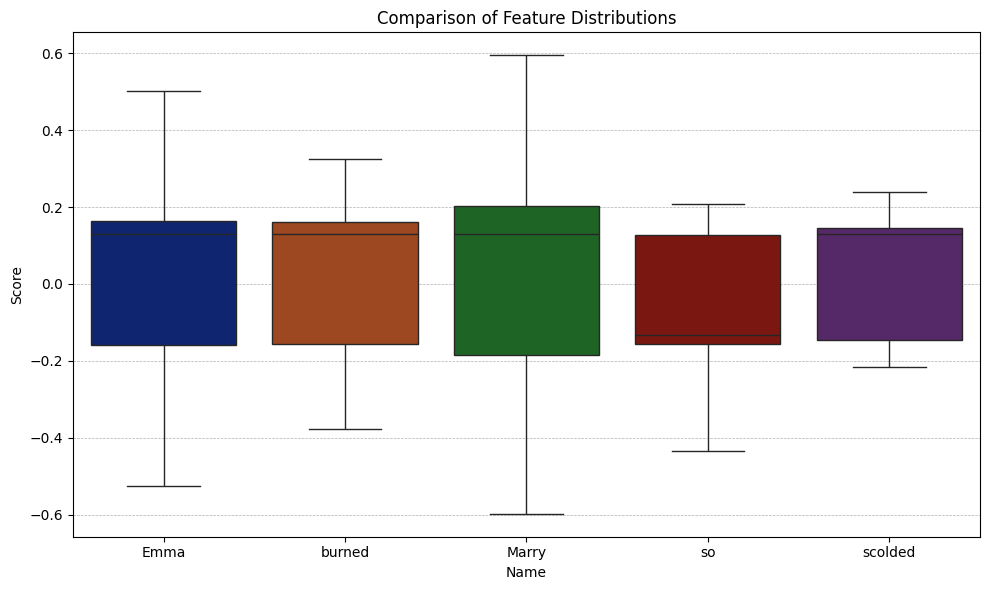

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create synthetic data (replace with your actual data)
# emma = np.random.normal(loc=0, scale=0.4, size=100)
# marry = np.random.normal(loc=0.1, scale=0.3, size=100)

data_name = []
for i in range(len(attention_name)):
    data_name = data_name + [attention_name[i]] * len(attention_scores[attention_name[i]])

data = {
    'Score': np.concatenate([attention_scores[name_] for name_ in attention_name]),
    'Name': data_name
}

df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Name', y='Score', data=df, palette='dark')  # You can also use palette='Set2' or any other
plt.title('Comparison of Feature Distributions')
plt.grid(True, axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()
